# 02 — Model Training

Training the GCN+LSTM model with real-time visualization. To change hyperparameters, use "default.yaml" in configs

In [1]:
import sys
sys.path.insert(0, '..')

import torch
import yaml
from pathlib import Path

from src.data.dataset import get_dataloaders, load_graph
from src.models.gcn_lstm import GCNLSTM
from src.training.trainer import Trainer
from src.viz.training_curves import plot_training_curves

%matplotlib inline

with open('../configs/default.yaml') as f:
    cfg = yaml.safe_load(f)

In [2]:
device = torch.device('mps' if torch.backends.mps.is_available() else
                       'cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

processed_dir = '../' + cfg['data']['processed_dir']
loaders = get_dataloaders(processed_dir, batch_size=cfg['data']['batch_size'],
                          num_workers=0)  # 0 workers for notebook
edge_index, edge_weight = load_graph(f'{processed_dir}/adj_mx.npz')

for name, loader in loaders.items():
    print(f'  {name}: {len(loader.dataset)} samples')

Device: mps
  train: 23967 samples
  val: 3416 samples
  test: 6844 samples


In [3]:
model = GCNLSTM(
    in_channels=cfg['model']['in_channels'],
    hidden_dim=cfg['model']['hidden_dim'],
    out_horizon=cfg['model']['out_horizon'],
    num_nodes=cfg['model']['num_nodes'],
    dropout=cfg['model']['dropout'],
)
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

Parameters: 38,412


In [4]:
trainer = Trainer(
    model=model,
    edge_index=edge_index,
    edge_weight=edge_weight,
    device=device,
    lr=cfg['training']['lr'],
    weight_decay=cfg['training']['weight_decay'],
    epochs=cfg['training']['epochs'],
    patience=cfg['training']['patience'],
    grad_clip=cfg['training']['grad_clip'],
    checkpoint_dir='../' + cfg['training']['checkpoint_dir'],
)
history = trainer.train(loaders['train'], loaders['val'])

Epoch   1/100 | Train Loss: 0.4704 | Val Loss: 0.4568 | Val MAE: 0.4568 | Val RMSE: 0.8240 | LR: 0.009998
  ✓ Best model saved (val_loss=0.4568)
Epoch   2/100 | Train Loss: 0.4593 | Val Loss: 0.4501 | Val MAE: 0.4501 | Val RMSE: 0.8176 | LR: 0.009990
  ✓ Best model saved (val_loss=0.4501)
Epoch   3/100 | Train Loss: 0.4533 | Val Loss: 0.4468 | Val MAE: 0.4468 | Val RMSE: 0.8072 | LR: 0.009978
  ✓ Best model saved (val_loss=0.4468)
Epoch   4/100 | Train Loss: 0.4503 | Val Loss: 0.4456 | Val MAE: 0.4456 | Val RMSE: 0.7993 | LR: 0.009961
  ✓ Best model saved (val_loss=0.4456)
Epoch   5/100 | Train Loss: 0.4482 | Val Loss: 0.4412 | Val MAE: 0.4412 | Val RMSE: 0.8025 | LR: 0.009938
  ✓ Best model saved (val_loss=0.4412)
Epoch   6/100 | Train Loss: 0.4467 | Val Loss: 0.4385 | Val MAE: 0.4385 | Val RMSE: 0.8031 | LR: 0.009911
  ✓ Best model saved (val_loss=0.4385)
Epoch   7/100 | Train Loss: 0.4464 | Val Loss: 0.4395 | Val MAE: 0.4395 | Val RMSE: 0.8119 | LR: 0.009880
Epoch   8/100 | Train Lo

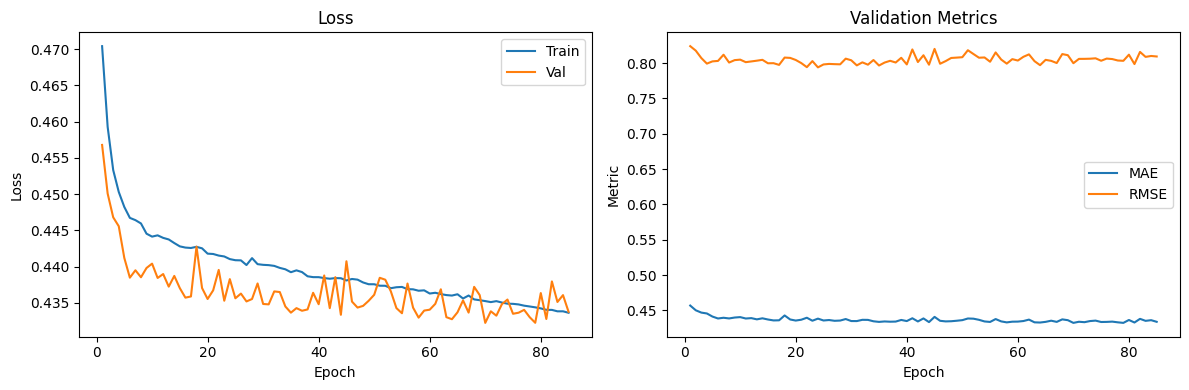

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs = range(1, len(history['train_loss']) + 1)
axes[0].plot(epochs, history['train_loss'], label='Train')
axes[0].plot(epochs, history['val_loss'], label='Val')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend()
axes[0].set_title('Loss')

axes[1].plot(epochs, history['val_mae'], label='MAE')
axes[1].plot(epochs, history['val_rmse'], label='RMSE')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Metric'); axes[1].legend()
axes[1].set_title('Validation Metrics')
plt.tight_layout()
plt.show()